In [1]:
import numpy as np
import pandas as pd
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import json
import re
import string
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("clinical_trials.csv")

In [3]:
df1=df.copy()

In [4]:
df.head()

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [5]:
df.shape

(60337, 16)

In [6]:
df.columns

Index(['source_condition_query', 'nct_id', 'title', 'official_title',
       'brief_summary', 'conditions', 'interventions', 'overall_status',
       'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age',
       'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  object
 1   nct_id                  60337 non-null  object
 2   title                   60337 non-null  object
 3   official_title          59551 non-null  object
 4   brief_summary           60337 non-null  object
 5   conditions              60336 non-null  object
 6   interventions           54276 non-null  object
 7   overall_status          60337 non-null  object
 8   study_type              60337 non-null  object
 9   phase                   23336 non-null  object
 10  sex                     60304 non-null  object
 11  minimum_age             57121 non-null  object
 12  maximum_age             28400 non-null  object
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  object
 15  cl

In [8]:
df["brief_summary"].dtype

dtype('O')

In [9]:
df.isnull().sum()

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [10]:
df['overall_status'].unique()

array(['UNKNOWN', 'COMPLETED', 'RECRUITING', 'NOT_YET_RECRUITING',
       'ACTIVE_NOT_RECRUITING', 'TERMINATED', 'WITHDRAWN',
       'ENROLLING_BY_INVITATION', 'APPROVED_FOR_MARKETING',
       'NO_LONGER_AVAILABLE', 'SUSPENDED', 'AVAILABLE',
       'TEMPORARILY_NOT_AVAILABLE'], dtype=object)

In [11]:
df = df.drop(
    columns=['nct_id', 'clinicaltrials_url', 'title'],
    errors='ignore'
)

In [12]:
df.head()

,source_condition_query,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria
0,breast cancer,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...
1,breast cancer,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...
2,breast cancer,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...
3,breast cancer,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...
4,breast cancer,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...


In [13]:
text_columns = [
    'official_title',
    'brief_summary',
    'conditions',
    'interventions',
    'eligibility_criteria',
    'minimum_age',
    'maximum_age'
]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")



In [14]:
categorical_columns = [
    'overall_status',
    'study_type',
    'phase',
    'sex',
    'healthy_volunteers'
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])


C:\Users\priyu\AppData\Local\Temp\ipykernel_30316\3852673412.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [15]:
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape:")
print(df.shape)

Missing values after cleaning:
source_condition_query    0
official_title            0
brief_summary             0
conditions                0
interventions             0
overall_status            0
study_type                0
phase                     0
sex                       0
minimum_age               0
maximum_age               0
healthy_volunteers        0
eligibility_criteria      0
dtype: int64

Dataset shape:
(60337, 13)


In [16]:
df = df.dropna(subset=["brief_summary", "source_condition_query"])

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 8


In [18]:
def clean_text(text):
    text = text.lower()
    
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [19]:
df["cleaned_summary"] = df["brief_summary"].apply(clean_text)

In [20]:
df["tokens"] = df["cleaned_summary"].apply(word_tokenize)

In [21]:
stop_words = set(stopwords.words("english"))

In [22]:
df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words])

In [23]:
df["tokens_no_stopwords"]

0        [breast, cancer, patients, often, perioperativ...
1        [many, breast, cancer, patients, experience, p...
2        [based, american, study, scherer, et, al, hypo...
3        [compare, effect, ropivacaine, versus, placebo...
4        [phase, dose, escalation, expansion, study, cl...
                               ...                        
60332    [zinc, nutritionally, essential, trace, elemen...
60333    [multiphase, patient, navigatorbased, program,...
60334    [sickle, cell, disease, scd, common, inherited...
60335    [promising, approach, treatment, genetic, dise...
60336    [sickle, cell, disease, scd, refers, group, he...
Name: tokens_no_stopwords, Length: 60337, dtype: object

In [24]:
lemmatizer = WordNetLemmatizer()

In [25]:
df["lemmatized_tokens"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

In [26]:
df["lemmatized_tokens"]

0        [breast, cancer, patient, often, perioperative...
1        [many, breast, cancer, patient, experience, ps...
2        [based, american, study, scherer, et, al, hypo...
3        [compare, effect, ropivacaine, versus, placebo...
4        [phase, dose, escalation, expansion, study, cl...
                               ...                        
60332    [zinc, nutritionally, essential, trace, elemen...
60333    [multiphase, patient, navigatorbased, program,...
60334    [sickle, cell, disease, scd, common, inherited...
60335    [promising, approach, treatment, genetic, dise...
60336    [sickle, cell, disease, scd, refers, group, he...
Name: lemmatized_tokens, Length: 60337, dtype: object

In [27]:
df.columns

Index(['source_condition_query', 'official_title', 'brief_summary',
       'conditions', 'interventions', 'overall_status', 'study_type', 'phase',
       'sex', 'minimum_age', 'maximum_age', 'healthy_volunteers',
       'eligibility_criteria', 'cleaned_summary', 'tokens',
       'tokens_no_stopwords', 'lemmatized_tokens'],
      dtype='object')

In [28]:
df["processed_text"] = df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens))

In [29]:
df1 = df.drop(
    columns=['tokens',
       'tokens_no_stopwords', 'lemmatized_tokens', 'processed_text',
       'summary_word_count'],
    errors='ignore'
)

In [30]:
df1.to_csv("processed_clinical_trials.csv", index=False)

In [31]:
text_data = df['processed_text'].fillna('')

In [33]:
df['summary_word_count'] = (
    df['brief_summary']
    .fillna('')
    .astype(str)
    .str.split()
    .str.len()
)

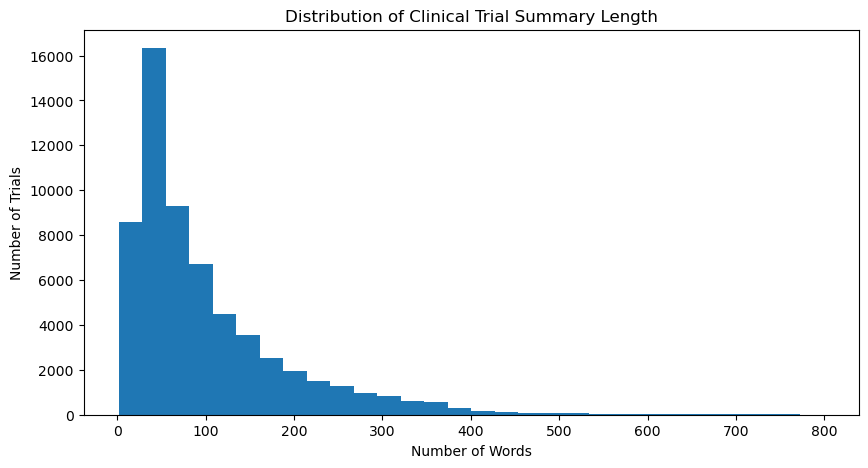

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['summary_word_count'],
    bins=30
)

plt.title('Distribution of Clinical Trial Summary Length')
plt.xlabel('Number of Words')
plt.ylabel('Number of Trials')
plt.show()

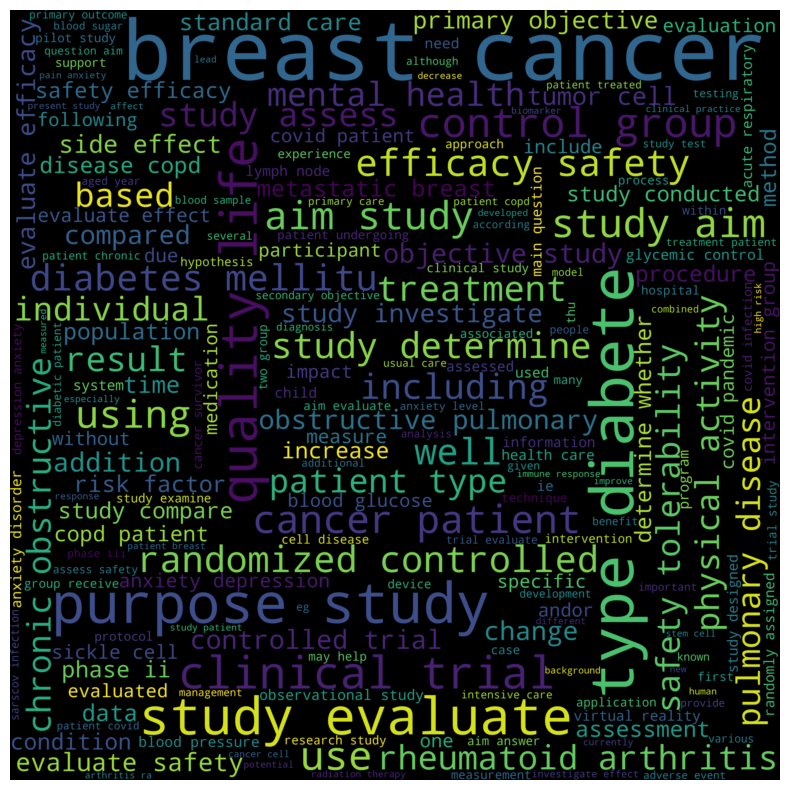

In [35]:
words_p = ' '.join(
    df['processed_text']
    .fillna('')
    .astype(str)
)


wc = WordCloud(
    width=4000,
    height=4000,
    background_color='black'
).generate(words_p)


plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

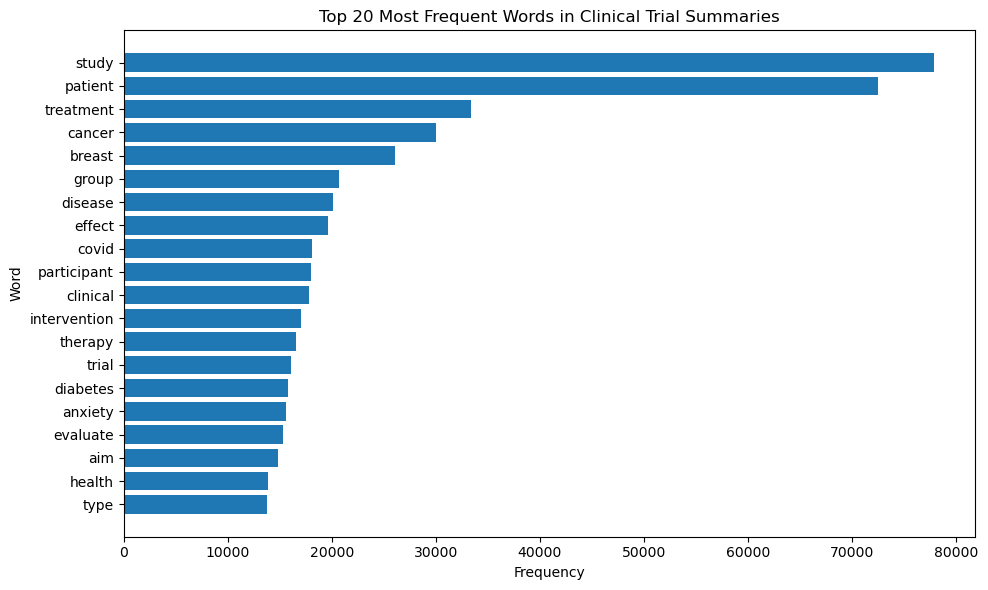

In [36]:
all_words = []

for words in df['lemmatized_tokens']:
    if isinstance(words, list):
        all_words.extend(words)


word_counts = Counter(all_words)
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_words['Word'][::-1],
    top_words['Frequency'][::-1]
)

plt.title('Top 20 Most Frequent Words in Clinical Trial Summaries')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

In [37]:
df["source_condition_query"].unique()

array(['breast cancer', 'covid-19',
       'chronic obstructive pulmonary disease', 'rheumatoid arthritis',
       'type 2 diabetes', 'glaucoma', 'anxiety', 'sickle cell anemia'],
      dtype=object)

In [38]:
df['source_condition_query'].value_counts()

source_condition_query
breast cancer                            16301
type 2 diabetes                          11467
covid-19                                 10153
anxiety                                   9286
chronic obstructive pulmonary disease     6181
rheumatoid arthritis                      3637
glaucoma                                  2173
sickle cell anemia                        1139
Name: count, dtype: int64

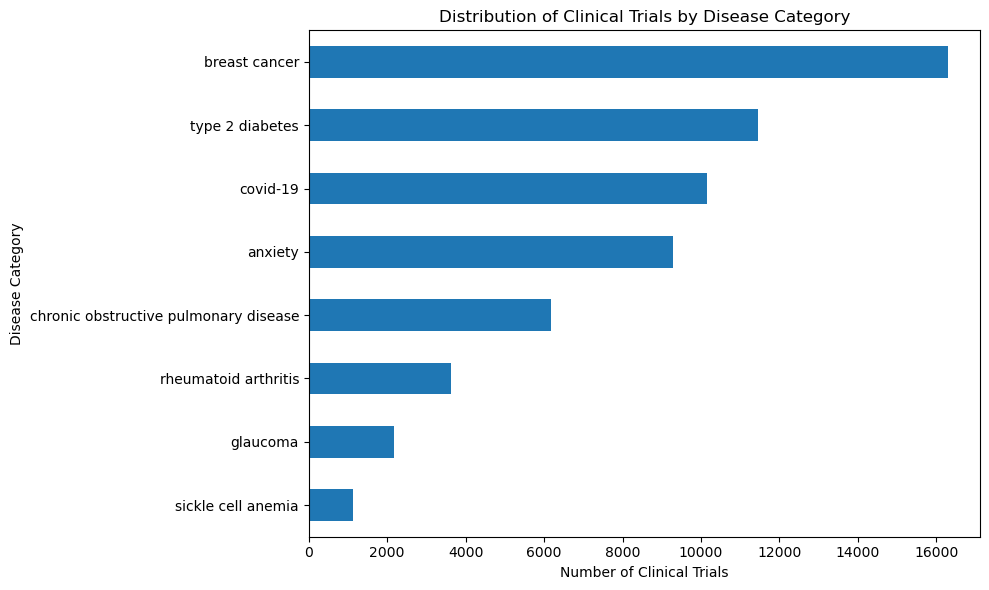

In [39]:
plt.figure(figsize=(10, 6))

df['source_condition_query'].value_counts().sort_values().plot(
    kind='barh'
)

plt.title('Distribution of Clinical Trials by Disease Category')
plt.xlabel('Number of Clinical Trials')
plt.ylabel('Disease Category')
plt.tight_layout()
plt.show()

In [40]:
label_encoder = LabelEncoder()

df['target_encoded'] = label_encoder.fit_transform(
    df['source_condition_query']
)

label_mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

print(label_mapping)

{'anxiety': np.int64(0), 'breast cancer': np.int64(1), 'chronic obstructive pulmonary disease': np.int64(2), 'covid-19': np.int64(3), 'glaucoma': np.int64(4), 'rheumatoid arthritis': np.int64(5), 'sickle cell anemia': np.int64(6), 'type 2 diabetes': np.int64(7)}


In [41]:
model_df = df[ ['processed_text', 'target_encoded']].dropna()
X = model_df['processed_text'].astype(str)
y = model_df['target_encoded'].astype(str)

In [42]:
len(model_df)

60337

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 48269
Testing samples: 12068


In [45]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (48269, 10000)
Testing TF-IDF shape: (12068, 10000)


In [46]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(X_test_tfidf)

In [47]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(X_test_tfidf)

In [48]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_pred = rf_model.predict(X_test_tfidf)

In [49]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

In [50]:
results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        'Naive Bayes',
        y_test,
        nb_pred
    )
)


results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        rf_pred
    )
)

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.945061   0.945968  0.945061  0.944921
1          Naive Bayes  0.899155   0.904951  0.899155  0.899540
2        Random Forest  0.939261   0.940830  0.939261  0.939014


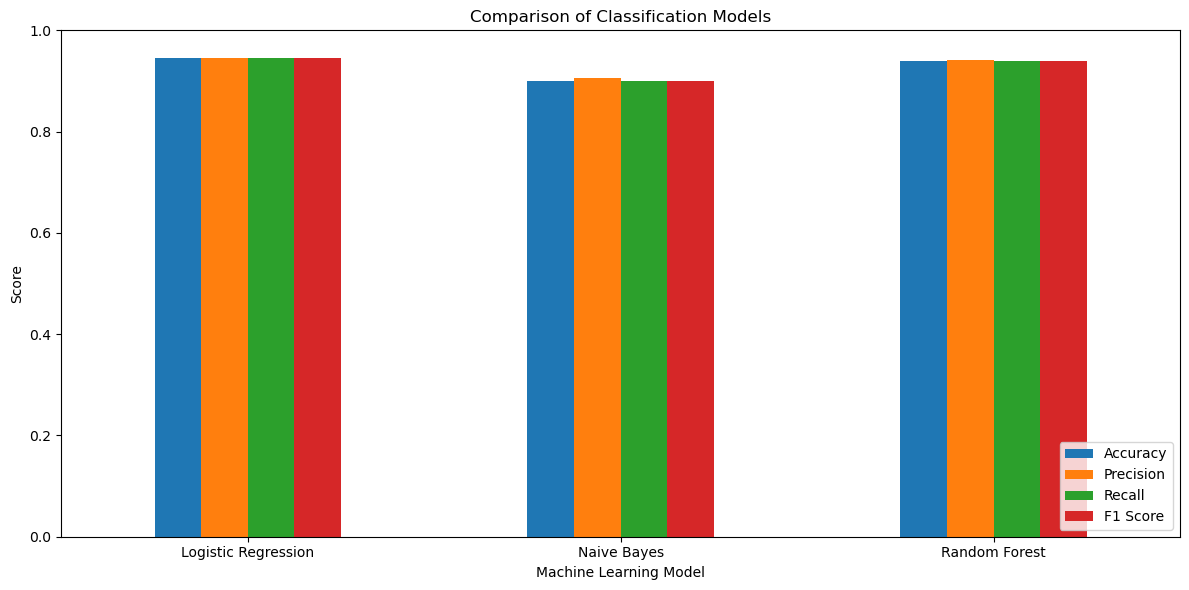

In [51]:
results_plot = results_df.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Comparison of Classification Models')
plt.xlabel('Machine Learning Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

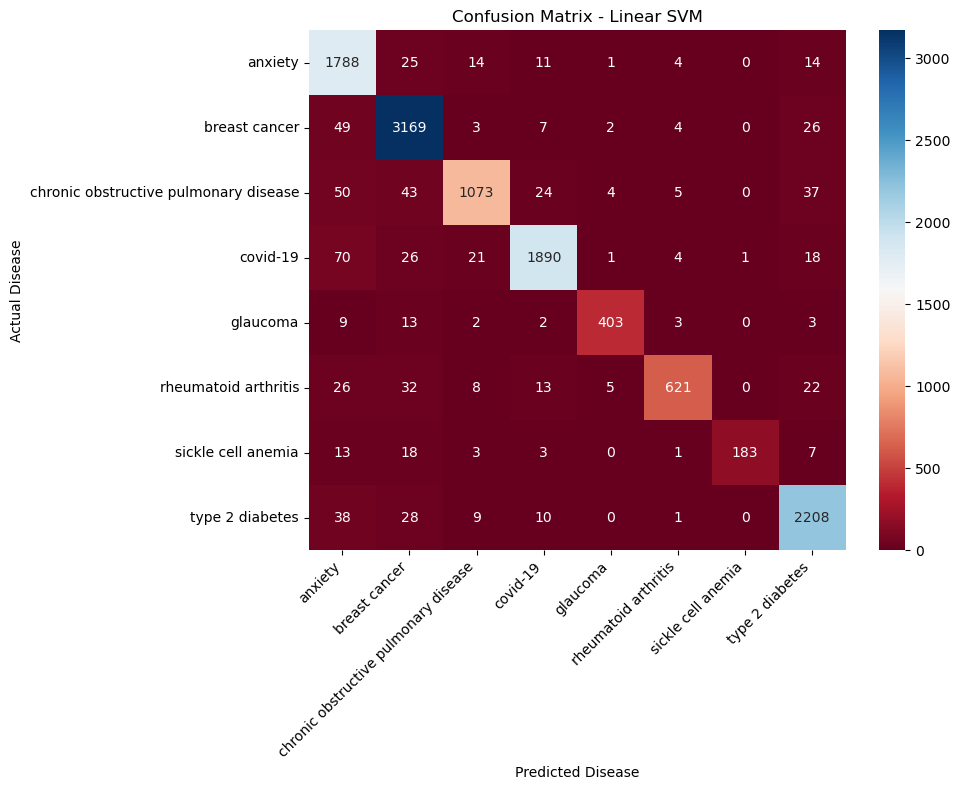

In [52]:
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    cmap="RdBu",
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
import pickle

with open("lr_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)